# 02 · The frozen contract

One HDF5 file pins everything the three methods must share: the mask, the bandpower
windows, the per-probe noise, the fixed galaxy alm, and the **42x42 NaMaster Gaussian
covariance** (`coupled=False`) that all of theory HMC, theory SBI and mock SBI whiten with.

`three_probe_noise_contract.py` · `three_probe_inference_contract.py` ·
`build_three_probe_selfconsistent_observation.py`

In [1]:
import json, pathlib, sys
import numpy as np, h5py
import matplotlib.pyplot as plt
ROOT = pathlib.Path("/mnt/ceph/users/spandey/ltu-godmax/GODMAX")
sys.path.insert(0, str(ROOT / "notebooks/SBI_validate/common"))
DATA = ROOT / "data/SBI_validate"
VAL  = DATA / "three_probe_mock/validation"
INF  = DATA / "three_probe_inference"
MSBI = DATA / "mock_sbi"
BLUE, ORANGE, GREEN, INK2, GRID = "#2a78d6", "#eb6834", "#1baf7a", "#52514e", "#dedcd6"
plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white",
                     "axes.edgecolor": GRID, "xtick.color": INK2, "ytick.color": INK2,
                     "font.size": 10.5, "axes.spines.top": False, "axes.spines.right": False})
SPECTRA = ["gy", "gkappa", "gtau"]
LBL = {"gg": r"$g \times g$", "gy": r"$g \times y$",
       "gkappa": r"$g \times \kappa_{\rm CMB}$", "gtau": r"$g \times \tau$"}

In [2]:
import mock_sbi_common as msc
ctx = msc.load_estimator_context()
mask = np.asarray(ctx.mask, float)
cov  = np.asarray(ctx.covariance, float)
ell  = np.asarray(ctx.effective_ell, float)
print(f"mask     <w> = {mask.mean():.6f}   <w^2> = {(mask**2).mean():.6f}   "
      f"nonzero = {(mask>0).mean():.4f}")
print(f"covariance {cov.shape}, symmetric, positive definite: "
      f"{np.allclose(cov, cov.T) and np.all(np.linalg.eigvalsh(cov) > 0)}")
print("bands:", len(ell), " ell_eff", ell.round(1))

mask     <w> = 0.401069   <w^2> = 0.400000   nonzero = 0.4054
covariance (42, 42), symmetric, positive definite: True
bands: 14  ell_eff [  90.   113.5  143.   180.   226.5  285.5  359.5  452.5  570.   718.
  904.  1137.5 1432.  1803. ]


### The mask, and the correlation matrix of the 42-vector

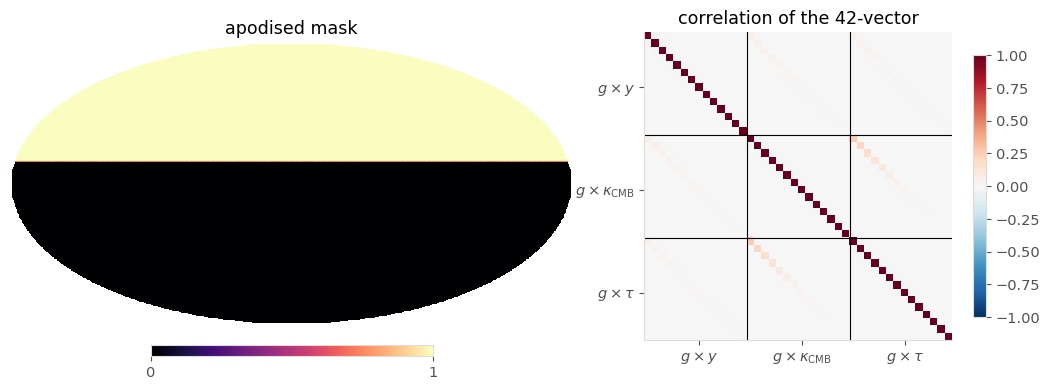

In [3]:
import healpy as hp
fig = plt.figure(figsize=(11.5, 4.0))
hp.mollview(mask, title="apodised mask", cbar=True, notext=True, cmap="magma",
            sub=(1, 2, 1), fig=fig.number)
ax = fig.add_subplot(1, 2, 2)
corr = cov / np.sqrt(np.outer(np.diag(cov), np.diag(cov)))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
for k in (14, 28): ax.axhline(k-.5, color="k", lw=.8); ax.axvline(k-.5, color="k", lw=.8)
ax.set_xticks([7, 21, 35]); ax.set_yticks([7, 21, 35])
ax.set_xticklabels([LBL[s] for s in SPECTRA]); ax.set_yticklabels([LBL[s] for s in SPECTRA])
ax.set_title("correlation of the 42-vector"); fig.colorbar(im, ax=ax, shrink=.85)

### Per-probe noise against the fiducial signal

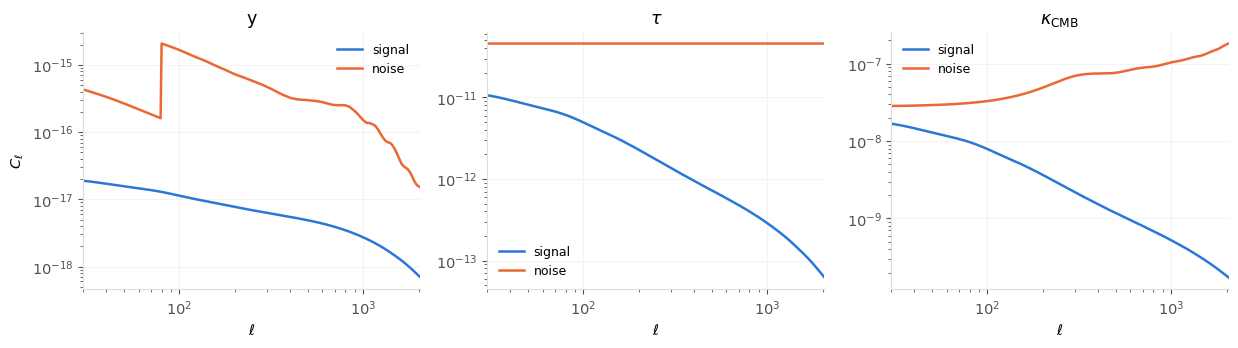

In [4]:
with h5py.File(msc.NOISE_CONTRACT_PATH, "r") as h:
    ln = np.asarray(h["ell"], float)
    noise = {k: np.asarray(h[f"noise_cls/{k}"], float)
             for k in ("y_effective", "tau", "kappa")}
    sig = {k: np.asarray(h[f"signal_cls/{k}"], float) for k in ("yy", "tautau", "kappakappa")}
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.6))
for ax, (n, s, t) in zip(axes, [("y_effective", "yy", "y"), ("tau", "tautau", r"$\tau$"),
                                ("kappa", "kappakappa", r"$\kappa_{\rm CMB}$")]):
    ax.loglog(ln, np.abs(sig[s]), color=BLUE, lw=1.8, label="signal")
    ax.loglog(ln, np.abs(noise[n]), color=ORANGE, lw=1.8, label="noise")
    ax.set_title(t); ax.set_xlabel(r"$\ell$"); ax.grid(alpha=.3, color=GRID)
    ax.legend(frameon=False, fontsize=9); ax.set_xlim(30, 2048)
axes[0].set_ylabel(r"$C_\ell$"); fig.tight_layout()

### The fiducial theory data vector with its error bars

gy       total S/N   87.1
gkappa   total S/N   81.2
gtau     total S/N   81.3


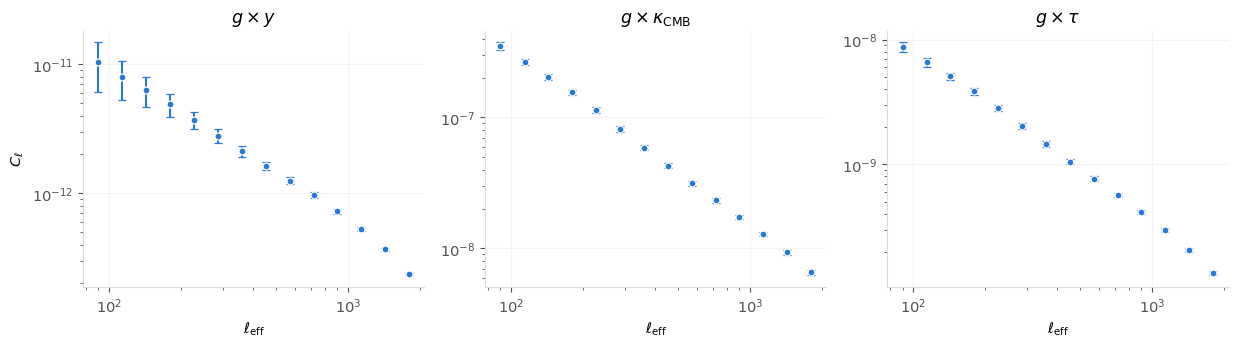

In [5]:
with h5py.File(INF / "observation_selfconsistent.h5", "r") as h:
    theory = np.asarray(h["data_vector"], float)
sd = np.sqrt(np.diag(cov))
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.6))
for k, (ax, s) in enumerate(zip(axes, SPECTRA)):
    sl = slice(14*k, 14*(k+1))
    ax.errorbar(ell, theory[sl], yerr=sd[sl], fmt="o", ms=5, color=BLUE, capsize=3,
                mec="white", mew=.9)
    ax.set_xscale("log"); ax.set_yscale("log"); ax.set_title(LBL[s])
    ax.set_xlabel(r"$\ell_{\rm eff}$"); ax.grid(alpha=.3, color=GRID)
    print(f"{s:<8} total S/N {np.sqrt(((theory[sl]/sd[sl])**2).sum()):6.1f}")
axes[0].set_ylabel(r"$C_\ell$"); fig.tight_layout()